In [61]:
from pathlib import Path
import sys
import numpy as np
import struct
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [37]:
_DTYPE_MAP = {
    "?": np.dtype("bool"),
    "b": np.dtype("int8"),
    "B": np.dtype("uint8"),
    "h": np.dtype("int16"),
    "H": np.dtype("uint16"),
    "i": np.dtype("int32"),
    "I": np.dtype("uint32"),
    "q": np.dtype("int64"),
    "Q": np.dtype("uint64"),
    "f": np.dtype("float32"),
    "d": np.dtype("float64"),
}

@dataclass
class LoadedBioFile:
    """Parsed representation of a collected .bio file."""

    path: Path
    signals: dict[str, dict]
    metadata: dict[str, object]

In [38]:

def load_bio_file(file_path: Path) -> LoadedBioFile: 
    """Read a .bio file produced by the streaming controller."""
    with open(file_path, "rb") as file_handle:
        n_signals = struct.unpack("<I", file_handle.read(4))[0]
        fs_base, n_samp_base = struct.unpack("<fI", file_handle.read(8))
        print(fs_base, n_samp_base)

        signals: dict[str, dict] = {}
        for _ in range(n_signals):
            sig_name_len = struct.unpack("<I", file_handle.read(4))[0]
            sig_name = struct.unpack(f"<{sig_name_len}s", file_handle.read(sig_name_len))[0].decode()
            fs, n_samp, n_ch, dtype_code = struct.unpack("<f2Ic", file_handle.read(13))

            signals[sig_name] = {
                "fs": fs,
                "n_samp": n_samp,
                "n_ch": n_ch,
                "dtype": _DTYPE_MAP[dtype_code.decode("ascii")],
            }

        has_trigger = struct.unpack("<?", file_handle.read(1))[0]
        has_trigger_str = struct.unpack("<?", file_handle.read(1))[0]


        timestamp = np.frombuffer(file_handle.read(8 * n_samp_base), dtype=np.float64).reshape(n_samp_base, 1)
        signals["timestamp"] = {"data": timestamp, "fs": fs_base}

        for sig_name, sig_data in signals.items():
            if sig_name == "timestamp":
                continue

            n_samp = int(sig_data.pop("n_samp"))
            n_ch = int(sig_data.pop("n_ch"))
            dtype = sig_data.pop("dtype")
            data = np.frombuffer(
                file_handle.read(dtype.itemsize * n_samp * n_ch), dtype=dtype
            ).reshape(n_samp, n_ch)
            sig_data["data"] = data

        if has_trigger:
            trigger = np.frombuffer(file_handle.read(4 * n_samp_base), dtype=np.uint32).reshape(n_samp_base, 1)
            signals["trigger"] = {"data": trigger, "fs": fs_base}

        if has_trigger_str:
            trigger_str: list[str] = []
            for _ in range(n_samp_base):
                (length,) = struct.unpack("<I", file_handle.read(4))
                if length == 0:
                    trigger_str.append("")
                else:
                    trigger_str.append(file_handle.read(length).decode("utf-8", errors="replace"))

            signals["trigger_str"] = {
                "data": np.array(trigger_str, dtype=object).reshape(n_samp_base, 1),
                "fs": fs_base,
            }

        
        metadata: dict[str, object] = {
            "fs_base": fs_base,
            "has_trigger": has_trigger,
            "has_trigger_str": has_trigger_str,
        }

    print(f"Loaded .bio file from {file_path} with signals: {list(signals.keys())} and metadata: {metadata}")
    return LoadedBioFile(path=file_path, signals=signals, metadata=metadata)

In [ ]:
data_path = r"example_data.bio"

In [40]:
loaded= load_bio_file(data_path)

30.00029945373535 4366
Loaded .bio file from C:\Users\giusy\OneDrive\Desktop\biogui_enzoclone\biogui\example_data.bio with signals: ['acquisition_number', 'tx_rx_id', 'ultrasound_cfg0_rx0', 'ultrasound_cfg1_rx1', 'ultrasound_cfg2_rx2', 'ultrasound_cfg3_rx3', 'ultrasound_cfg4_rx4', 'ultrasound_cfg5_rx5', 'imu', 'timestamp', 'trigger', 'trigger_str'] and metadata: {'fs_base': 30.00029945373535, 'has_trigger': True, 'has_trigger_str': True}


In [41]:
import pandas as pd
def build_dataframe(loaded: LoadedBioFile) -> pd.DataFrame:

    signals = loaded.signals
    if "imu" in signals.keys():
        samples_per_acquisition = 397
    else:
        samples_per_acquisition = 400
    # BUILD ALL the utiles
    counter_values = np.hstack(signals["acquisition_number"]["data"])
    rx_ids        = np.hstack(signals["tx_rx_id"]["data"])


    if "imu" in signals.keys():
        imu_data = signals["imu"]["data"]
    if "trigger" in signals.keys():
        trigger_data = np.hstack(signals["trigger"]["data"])
    if "trigger_str" in signals.keys():
        trigger_data_str = np.hstack(signals["trigger_str"]["data"])
        
    # Check if we have data losses
    N = int(counter_values[-1]+1)
    full_counter = np.arange(0, N )
    full_tx_rx_id = np.nan * np.ones(N)
    full_tx_rx_id[counter_values] = rx_ids

    if "trigger" in signals.keys():
        trigger_data_full = np.nan * np.ones(N)
    if "trigger_str" in signals.keys():
        trigger_str_full = np.full(N, "", dtype=object)

    if "imu" in signals.keys():
        imu_x_full = np.nan * np.ones(N)
        imu_y_full = np.nan * np.ones(N)
        imu_z_full = np.nan * np.ones(N)

    if len(full_counter)!=len(counter_values):
        print("Data Losses!")

    if "trigger" in signals.keys():
        trigger_data_full[counter_values] = trigger_data
    if "trigger_str" in signals.keys():
        trigger_str_full[counter_values] = trigger_data_str
    if "imu" in signals.keys():
        imu_x_full[counter_values] = imu_data[:, 0]
        imu_y_full[counter_values] = imu_data[:, 1]
        imu_z_full[counter_values] = imu_data[:, 2]

    df_session = pd.DataFrame()

    for sig_name, sig_data in signals.items():
        if sig_name in ["timestamp", "trigger", "trigger_str", "imu", "acquisition_number", "tx_rx_id"]:
            continue

        rx_data = sig_data["data"]
        n_samp, n_ch = rx_data.shape

        n_acq = n_samp // samples_per_acquisition
        if n_acq == 0:
            print(f"Warning: Signal '{sig_name}' skipped (not enough samples).")
            continue

        trunc = n_acq * samples_per_acquisition
        data_reshaped = rx_data[:trunc, :].reshape(n_acq, samples_per_acquisition)

        us_id = int(sig_name[-1])
        counter_curr = counter_values[rx_ids == us_id]


        # protect against mismatch
        n = min(len(counter_curr), len(data_reshaped))
        counter_curr = counter_curr[:n]
        data_reshaped = data_reshaped[:n]
        if n == 0:
            continue

        # expected step for this transducer (round-robin cadence)
        diffs = np.diff(counter_curr)
        if len(diffs) == 0:
            step = 1
        else:
            # mode of diffs (most common increment)
            step = int(pd.Series(diffs).mode().iloc[0])

        # detect losses relative to expected step
        loss_mask = diffs != step
        if np.any(loss_mask):
            print(f"Data losses for {sig_name} (expected step={step})")

        # series indexed by counter
        s = pd.Series(list(data_reshaped), index=counter_curr, name=f'tx_{us_id}')
        s = s[~s.index.duplicated(keep="first")]  # optional safety

        # expected counter sequence for THIS transducer
        start = int(s.index.min())
        end   = int(s.index.max())
        full_counter = np.arange(start, end + step, step)

        nan_waveform = np.full(samples_per_acquisition, np.nan)
        s = s.reindex(full_counter, fill_value=nan_waveform)

        df_session = pd.concat([df_session, s.to_frame()], axis=1)

    # order chronologically
    df_session = df_session.sort_index()
    # fill with the rest

    if "trigger" in signals.keys():
        df_session['Label'] = trigger_data_full[:len(df_session)]
    if "trigger_str" in signals.keys():
        df_session['Label_str'] = trigger_str_full[:len(df_session)]
    if "imu" in signals.keys():
        df_session['imu_x'] = imu_x_full[:len(df_session)]
        df_session['imu_y'] = imu_y_full[:len(df_session)]
        df_session['imu_z'] = imu_z_full[:len(df_session)]  
    df_session['rx_id'] = full_tx_rx_id[:len(df_session)]

    return df_session, samples_per_acquisition

In [ ]:

_NON_CHANNEL_COLUMNS = {"Label", "Label_str", "imu_x", "imu_y", "imu_z", "rx_id", "timestamp", "trigger", "trigger_str"}


def _resolve_enabled_channels(dataframe: pd.DataFrame, plot_options: dict | None) -> list[str]:
    channel_columns = [
        column
        for column in dataframe.columns
        if column not in _NON_CHANNEL_COLUMNS
    ]
    if not plot_options:
        return channel_columns

    enabled_map = plot_options.get("enabledChannels")
    if isinstance(enabled_map, dict):
        filtered = [column for column in channel_columns if enabled_map.get(column, True)]
        return filtered or channel_columns

    enabled_list = plot_options.get("enabledChannels")
    if isinstance(enabled_list, (list, tuple, set)):
        filtered = [column for column in channel_columns if column in enabled_list]
        return filtered or channel_columns

    return channel_columns

def first_non_empty_waveform(series: pd.Series) -> np.ndarray | None:
    for waveform in series.to_numpy():
        if waveform is None:
            continue
        array = np.asarray(waveform, dtype=float).ravel()
        if array.size > 0:
            return array
    return None

def _process_waveforms(waveforms: np.ndarray, plot_options: dict | None) -> np.ndarray:
    """Apply ultrasound preprocessing along the depth axis for all frames."""
    print("Processing waveforms with shape", waveforms.shape)
    filter_instance = _build_filter(plot_options)
    _, _, _, apply_envelope, _ = _get_processing_config(plot_options)

    processed = waveforms  # shape: (n_depth_samples, n_frames); filter axis=0 → depth
    if filter_instance is not None:
        processed = filter_instance.filter_data(processed)
    if apply_envelope:
        processed = UltrasoundFilter.get_envelope(processed)
    return processed

    

In [43]:
dataframe, num_samples = build_dataframe(loaded)
channel_columns = [col for col in dataframe.columns if col.startswith("tx_")]

Data Losses!


In [44]:

from scipy import signal as ss
from scipy.signal import hilbert
class UltrasoundFilter:
    """
    Bandpass filter and envelope detector for ultrasound signals.

    Online/runtime convention
    -------------------------
    Online data uses axis=0 as sample axis.

    Expected shapes:
    - (n_samples,)
    - (n_samples, n_channels)

    Offline/post-acquisition convention
    -----------------------------------
    Post-acquisition data uses axis=-1 as sample axis.

    Expected shapes:
    - (n_samples,)
    - (..., n_samples)

    Example:
    - (76, 397) means 76 independent waveforms, each with 397 samples.
    """

    def __init__(
        self,
        sampling_freq: float,
        low_cutoff: float,
        high_cutoff: float,
        trans_width: float = 0.2e6,
        n_taps: int = 31,
        enabled: bool = True,
    ) -> None:
        self._sampling_freq = sampling_freq
        self._low_cutoff = low_cutoff
        self._high_cutoff = high_cutoff
        self._trans_width = trans_width
        self._n_taps = n_taps
        self._enabled = enabled

        self._filt_b: np.ndarray | None = None
        self._filt_a = 1

        if self._enabled:
            self._design_filter()

    def _design_filter(self) -> None:
        """Design bandpass filter using Remez algorithm."""
        if not self._enabled:
            return

        nyquist = self._sampling_freq / 2.0

        low_stop = self._low_cutoff - self._trans_width
        high_stop = self._high_cutoff + self._trans_width

        if low_stop < 0:
            print(f"Warning: Lower transition band is negative ({low_stop / 1e6:.3f} MHz).")
            print(
                f"  Low cutoff: {self._low_cutoff / 1e6:.3f} MHz, "
                f"Transition width: {self._trans_width / 1e6:.3f} MHz"
            )
            print("  Adjusting low_stop to 0 Hz...")
            low_stop = 0.0

        if high_stop > nyquist:
            print(
                f"Warning: Upper transition band exceeds Nyquist "
                f"({high_stop / 1e6:.3f} MHz > {nyquist / 1e6:.3f} MHz)."
            )
            print("  Adjusting high_stop to Nyquist...")
            high_stop = nyquist

        bands = [0.0, low_stop, self._low_cutoff, self._high_cutoff, high_stop, nyquist]

        for i in range(len(bands) - 1):
            if bands[i] >= bands[i + 1]:
                print("Error: Non-monotonic filter bands. Filter disabled.")
                print(f"  Bands: {[f'{f / 1e6:.3f} MHz' for f in bands]}")
                self._enabled = False
                self._filt_b = None
                return

        print(f"Designing filter with bands: {[f'{f / 1e6:.3f} MHz' for f in bands]}")

        try:
            self._filt_b = ss.remez(
                self._n_taps,
                bands,
                [0, 1, 0],
                fs=self._sampling_freq,
                maxiter=2500,
            )
            print(f"Filter designed successfully. Gain at passband: {np.sum(self._filt_b):.3f}")
        except Exception as exc:
            print(f"Error: Filter design failed: {exc}")
            self._enabled = False
            self._filt_b = None

    def filter_data_postacq(self, data_in: np.ndarray) -> np.ndarray:
        """
        Apply bandpass filter independently to each post-acquisition waveform.

        Offline convention:
        - sample axis is axis=-1

        Expected shapes:
        - (n_samples,)
        - (..., n_samples)

        Example:
        - (76, 397): 76 independent waveforms, each with 397 samples.
        """
        if not self._enabled or self._filt_b is None:
            return data_in

        return ss.filtfilt(
            self._filt_b,
            self._filt_a,
            data_in,
            axis=-1,
        )

    @staticmethod
    def get_envelope_postacq(data_in: np.ndarray) -> np.ndarray:
        """
        Calculate envelope independently for each post-acquisition waveform.

        Offline convention:
        - sample axis is axis=-1
        """
        return np.abs(hilbert(data_in, axis=-1))

    @staticmethod
    def apply_log_compression_postacq(
        data: np.ndarray,
        dynamic_range: float = 40.0,
        normalize_per_waveform: bool = True,
    ) -> np.ndarray:
        """
        Apply B-mode style log compression to post-acquisition data.

        Offline convention:
        - sample axis is axis=-1

        If normalize_per_waveform=True:
        - each waveform is normalized independently along the last axis.

        If normalize_per_waveform=False:
        - one global peak is used for the full array.
        """
        amplitude = np.abs(data).astype(np.float64)
        amplitude = np.where(np.isfinite(amplitude), amplitude, 0.0)

        if normalize_per_waveform:
            peak = np.max(amplitude, axis=-1, keepdims=True)
        else:
            peak = np.max(amplitude)

        valid = np.isfinite(peak) & (peak > 0.0)
        safe_peak = np.where(valid, peak, 1.0)

        ratio = amplitude / safe_peak

        if dynamic_range >= 1.0:
            compressed = np.zeros_like(amplitude, dtype=np.float64)
            positive = ratio > 0.0

            compressed[positive] = (
                20.0 * np.log10(ratio[positive]) + dynamic_range
            )
            compressed = 255.0 * compressed / dynamic_range
        else:
            compressed = np.power(ratio, dynamic_range) * 255.0

        compressed = np.where(valid, compressed, 0.0)

        return np.clip(compressed, 0.0, 255.0)

def process_single(raw: np.ndarray, proc_mode='log') -> [np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    """
    Process one (n_frames, n_depth) matrix with the current mode and filter.

    Returns (n_frames, n_depth).
    """
    data = np.asarray(raw, dtype=float)
    data_raw = data

    if proc_mode == "raw":
        return data_raw,None, None, None

    filt = build_current_filter()
    if filt is not None:
        data_filt = filt.filter_data_postacq(data)

    if proc_mode == "filtered":
        return data_raw, data_filt, None, None

    data_env = UltrasoundFilter.get_envelope_postacq(data_filt)

    # envelope / log
    if proc_mode == "hilbert":
        return data_raw, data_filt, data_env, None
    if proc_mode == "log":
        data_log = UltrasoundFilter.apply_log_compression_postacq(data_env)
        return data_raw, data_filt, data_env, data_log
        

def build_current_filter() -> UltrasoundFilter | None:
    """Build a bandpass filter from the current UI settings, or None."""

    adc_fs = 8e6
    transmission_freq = 2.25e6

    bandwidth_fraction = 0.3
    half_band = max(transmission_freq * bandwidth_fraction / 2.0, 1.0)
    low_cutoff = max(0.0, transmission_freq - half_band)
    high_cutoff = min(adc_fs / 2.0, transmission_freq + half_band)

    return UltrasoundFilter(
        sampling_freq=adc_fs,
        low_cutoff=low_cutoff,
        high_cutoff=high_cutoff,
        enabled=True,
    )

def process_single(raw: np.ndarray, proc_mode='log', filt: UltrasoundFilter | None = None) -> [np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    """
    Process one (n_frames, n_depth) matrix with the current mode and filter.

    Returns (n_frames, n_depth).
    """
    data = np.asarray(raw, dtype=float)
    data_raw = data

    if proc_mode == "raw":
        return data_raw,None, None, None

    if filt is None:
        filt = build_current_filter()
    if filt is not None:
        data_filt = filt.filter_data_postacq(data)

    if proc_mode == "filtered":
        return data_raw, data_filt, None, None

    data_env = UltrasoundFilter.get_envelope_postacq(data_filt)

    # envelope / log
    if proc_mode == "hilbert":
        return data_raw, data_filt, data_env, None
    if proc_mode == "log":
        data_log = UltrasoundFilter.apply_log_compression_postacq(data_env)
        return data_raw, data_filt, data_env, data_log
        

In [45]:
def filter_raw_dataframe(dataframe):
    filt = build_current_filter()
    tx_cols = [col for col in dataframe.columns if col.startswith("tx_")]

    raw_matrices: dict[str, np.ndarray] = {}
    new_cols = {}

    for col in tx_cols:
        us_curr = dataframe[col].dropna()

        if us_curr.empty:
            continue

        us_idx = us_curr.index
        raw_matrix = np.stack(us_curr.to_numpy(), axis=0)

        data_raw, data_filt, data_env, data_log = process_single(
            raw_matrix,
            proc_mode="log",
            filt=filt,
        )

        raw_matrices[col] = raw_matrix

        #new_cols[f"{col}_raw"] = pd.Series(data_raw.tolist(), index=us_idx)
        new_cols[f"{col}_filt"] = pd.Series(data_filt.tolist(), index=us_idx)
        new_cols[f"{col}_env"] = pd.Series(data_env.tolist(), index=us_idx)
        new_cols[f"{col}_log"] = pd.Series(data_log.tolist(), index=us_idx)

    processed_df = pd.DataFrame(new_cols, index=dataframe.index)

    dataframe = pd.concat([dataframe, processed_df], axis=1)

    return dataframe, raw_matrices

In [46]:
dataframe_final,_ = filter_raw_dataframe(dataframe.copy())

Designing filter with bands: ['0.000 MHz', '1.712 MHz', '1.913 MHz', '2.587 MHz', '2.788 MHz', '4.000 MHz']
Filter designed successfully. Gain at passband: -0.101


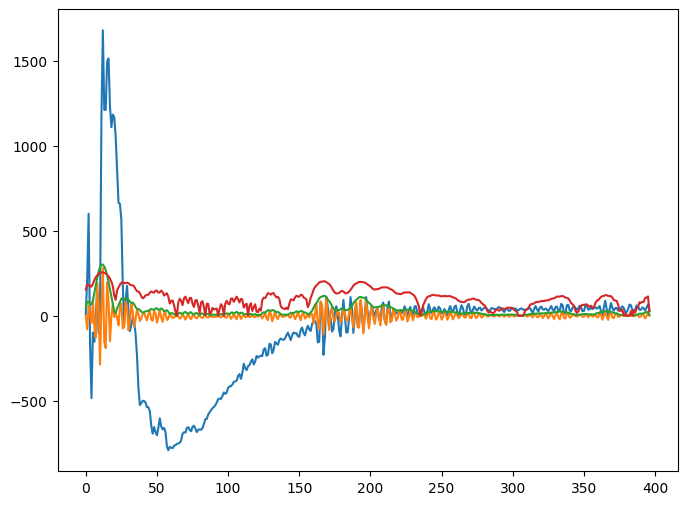

In [47]:
# Visualize output of the processing
plt.figure(figsize=(8,6))
curr_row = dataframe_final.iloc[0]
plt.plot(curr_row["tx_0"], label='raw_data')
plt.plot(curr_row["tx_0_filt"], label='filtered')
plt.plot(curr_row["tx_0_env"], label='envelope')
plt.plot(curr_row["tx_0_log"], label='log')

In [48]:
# Now, align everything to create an "scanning dataset"
def build_us_dataset_for_every_scan(dataframe_final, tx_cols, num_transducers, has_imu, has_trigger, has_trigger_str):
    # Step 1. Fowrd-fill US data to align with scans (one scan per row, with all channels)
    
    dataframe_final[tx_cols] = dataframe_final[tx_cols].ffill()

    # label/imu logic (optional: rolling over last full round)
    w = num_transducers
    if has_trigger:
        labels = dataframe_final["Label"]
    if has_trigger_str:
        labels_str = dataframe_final["Label_str"]

    # numeric labels
    same_label = labels.rolling(w, min_periods=1).apply(lambda x: x.nunique(), raw=False).eq(1)
    dataframe_final["label"] = np.where(same_label, labels, -1).astype(int)
    # string labels: roll on integer codes, then select original strings
    codes = labels_str.astype("category").cat.codes  # int series, NaN -> -1

    same_label_str = codes.rolling(w, min_periods=1).apply(lambda x: x.nunique() == 1, raw=False).astype(bool)
    dataframe_final["label_str"] = np.where(same_label_str, labels_str, "nan")  # or np.nan / "UNKNOWN"

    dataframe_final.loc[dataframe_final["Label_str"] == "init", "Label_str"] = "nan"
    if has_imu:
        dataframe_final[["imu_x", "imu_y", "imu_z"]] = dataframe_final[["imu_x", "imu_y", "imu_z"]].rolling(w, min_periods=1).mean()

    dataframe_final = dataframe_final.drop(columns=["rx_id", "Label"])
    # just drop first 4
    dataframe_final = dataframe_final.iloc[w:].reset_index(drop=True)

    return dataframe_final

In [49]:
df= build_us_dataset_for_every_scan(dataframe_final.copy(), tx_cols=dataframe_final.columns[dataframe_final.columns.str.contains("tx_")], num_transducers=len(channel_columns), has_imu="imu_x" in dataframe.columns, has_trigger="Label" in dataframe.columns, has_trigger_str="Label_str" in dataframe.columns)

# Basic Feature Extraction

In [50]:
acd_start_delay = 5e-6
SPEED_SOUND = 1500  # m/s
MSP_FREQ = 8e6

depth_lost = ((acd_start_delay * SPEED_SOUND)/2)*1000  # speed of sound in tissue ~1500 m/s

recording_time=num_samples/MSP_FREQ
total_depth = (SPEED_SOUND * recording_time / 2)*1000
print(f"Total depth range: {total_depth:.2f} mm")

FIRST_SAMPLES_TO_DISCARD = 10

samples_to_time = FIRST_SAMPLES_TO_DISCARD / MSP_FREQ
depth_discarded = (samples_to_time * SPEED_SOUND / 2) * 1000

total_depth_lost = depth_lost + depth_discarded
print(f"Depth lost due to ACD start delay: {depth_lost:.2f} mm")
print(f"Depth lost due to discarding first {FIRST_SAMPLES_TO_DISCARD} samples: {depth_discarded:.2f} mm")
print(f"Total depth lost: {total_depth_lost:.2f} mm")

Total depth range: 37.22 mm
Depth lost due to ACD start delay: 3.75 mm
Depth lost due to discarding first 10 samples: 0.94 mm
Total depth lost: 4.69 mm


In [51]:
# compute basics features for US data
# Note, we consider:
# mean, max, std, min
WINDOW_SIZE_SAMPLES = 25            # change this parameter to adjust window size

num_windows = num_samples // WINDOW_SIZE_SAMPLES

In [52]:
def compute_features_per_window(us_window,features_to_extract: list[str]) -> dict[str, float]:
    features = {}
    if "mean" in features_to_extract:
        features[f"mean"] = np.mean(us_window)
    if "max" in features_to_extract:
        features[f"max"] = np.max(us_window)
    if "std" in features_to_extract:
        features[f"std"] = np.std(us_window)
    if "min" in features_to_extract:
        features[f"min"] = np.min(us_window)
    return features

def compute_features_per_scan(channel_data, num_samples:int, features_to_extract: list[str]) -> dict[str, list[float]]:
    features_per_window = []
    win_id = 0
    for start in range(FIRST_SAMPLES_TO_DISCARD, num_samples, WINDOW_SIZE_SAMPLES):
        end = start + WINDOW_SIZE_SAMPLES
        if end > num_samples:
            end = num_samples
        window = channel_data[start:end]
        features = compute_features_per_window(window, features_to_extract=features_to_extract)
        features_per_window.append(features)
        win_id+=1

    features_scan ={}
    for feature in features_to_extract:
        feature_list = []
        for idx in range(len(features_per_window)):
            feature_list.append(features_per_window[idx][feature])
        features_scan[feature] = feature_list

    return features_scan


In [ ]:
# Note: for simplicity, we extract features evry num_transucers scan
step = len(channel_columns)
features_to_extract = ["mean", "max", "std", "min"]
ch_to_consider = channel_columns  # just one channel for now, but can be easily extended to multiple channels
processing_step = "env"
col_to_extract = [f"{col}_{processing_step}" for col in ch_to_consider]

df_features = pd.DataFrame()
idx_to_consider = range(0, len(df), step)

df_features = df.loc[idx_to_consider, col_to_extract + ["label", "label_str"]].copy()

In [54]:
step = len(channel_columns)

features_to_extract = ["mean", "max", "std", "min"]
ch_to_consider = channel_columns
processing_step = "env"
feature_columns = []
idx_to_consider = range(0, len(df), step)

col_to_extract = [f"{col}_{processing_step}" for col in ch_to_consider]

df_features = df.loc[
    idx_to_consider,
    col_to_extract + ["label", "label_str"],
].copy()

for channel in ch_to_consider:
    signal_col = f"{channel}_{processing_step}"

    for feature in features_to_extract:
        out_col = f"{signal_col}_{feature}"
        feature_columns.append(out_col)
        df_features[out_col] = df_features[signal_col].apply(
            lambda x: compute_features_per_scan(
                np.asarray(x),
                num_samples=len(x),
                features_to_extract=[feature],
            )[feature]
            if x is not None and not pd.isna(x).any()
            else np.nan
        )

# Feature Visualization

In [55]:
# Expand list-valued feature columns into scalar columns
expanded_feature_dfs = []

for col in feature_columns:
    expanded = pd.DataFrame(
        df_features[col].tolist(),
        index=df_features.index,
    )

    expanded.columns = [
        f"{col}_win{i}" for i in range(expanded.shape[1])
    ]

    expanded_feature_dfs.append(expanded)

df_features_expanded = pd.concat(
    [
        df_features[["label", "label_str"]],
        *expanded_feature_dfs,
    ],
    axis=1,
)

pca_feature_columns = [
    c for c in df_features_expanded.columns
    if c not in ["label", "label_str"]
]

In [ ]:
# Here you can count how many samples we have for each label
df_features["label_str"].value_counts()

label_str
front_rotclosed    147
start              146
pour               146
front_open         145
rest                89
nan                 38
                    12
init                 4
Name: count, dtype: int64

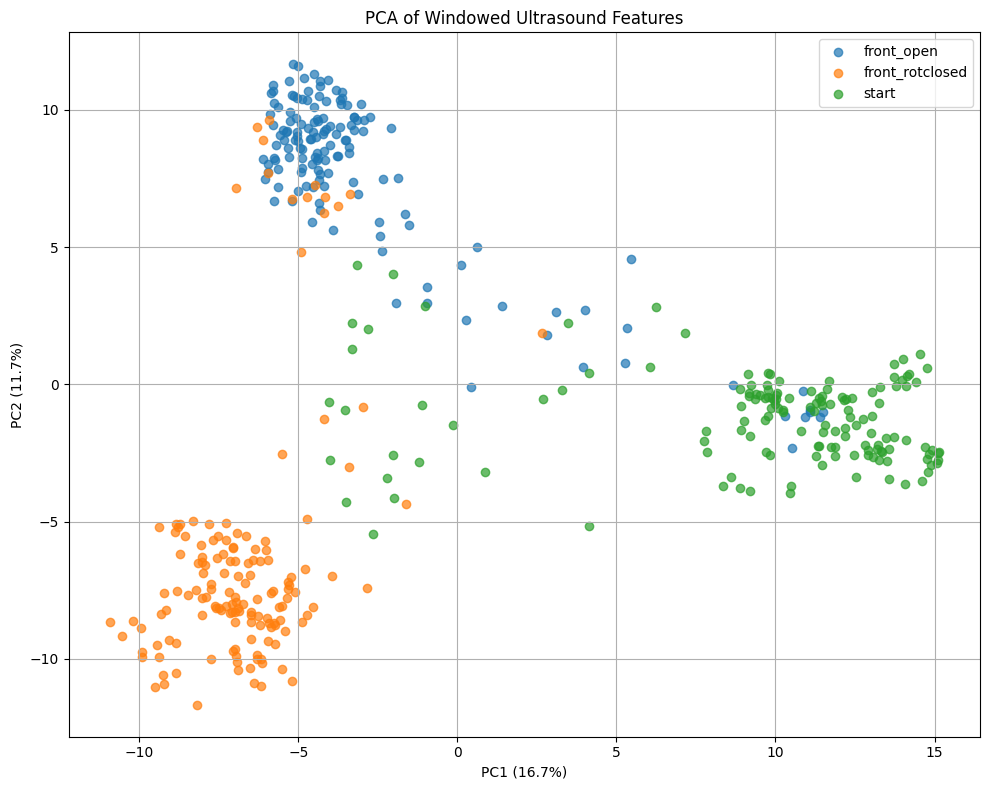

Explained variance ratio: [0.16739024 0.1168884 ]
Total explained variance: 0.2842786462327351


In [58]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Keep labels of interest
label_of_interest = [
    "start",
    "front_rotclosed",
    "front_open",
    "front_open"
    # "side_rotclosed",
    # "side_open",
]

df_pca = df_features_expanded[
    df_features_expanded["label_str"].isin(label_of_interest)
].copy()

# Remove rows with missing features
df_pca = df_pca.dropna(subset=pca_feature_columns)

X = df_pca[pca_feature_columns].to_numpy()
y = df_pca["label_str"].to_numpy()

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

for label in np.unique(y):
    mask = y == label
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        alpha=0.7,
    )

plt.xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
plt.title("PCA of Windowed Ultrasound Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Top features contributing to PC1:
tx_0_env_max_win7      0.110472
tx_0_env_mean_win6     0.109147
tx_0_env_max_win6      0.108841
tx_0_env_mean_win7     0.104108
tx_5_env_max_win14     0.101506
tx_5_env_std_win14     0.097941
tx_0_env_mean_win4     0.096307
tx_4_env_mean_win3     0.095820
tx_0_env_std_win7      0.095232
tx_4_env_mean_win14    0.094955
tx_0_env_std_win6      0.094882
tx_1_env_mean_win3     0.094535
tx_5_env_mean_win14    0.094168
tx_4_env_max_win14     0.093981
tx_4_env_max_win3      0.093965
Name: PC1, dtype: float64

Top features contributing to PC2:
tx_2_env_mean_win2     0.114512
tx_1_env_mean_win10    0.111406
tx_1_env_max_win7      0.110162
tx_1_env_mean_win7     0.109722
tx_1_env_max_win10     0.107046
tx_1_env_mean_win9     0.106913
tx_2_env_max_win2      0.106482
tx_1_env_max_win9      0.106159
tx_1_env_std_win7      0.105204
tx_4_env_max_win12     0.100958
tx_1_env_mean_win8     0.100938
tx_2_env_std_win2      0.100279
tx_1_env_max_win8      0.099644
tx_4_env

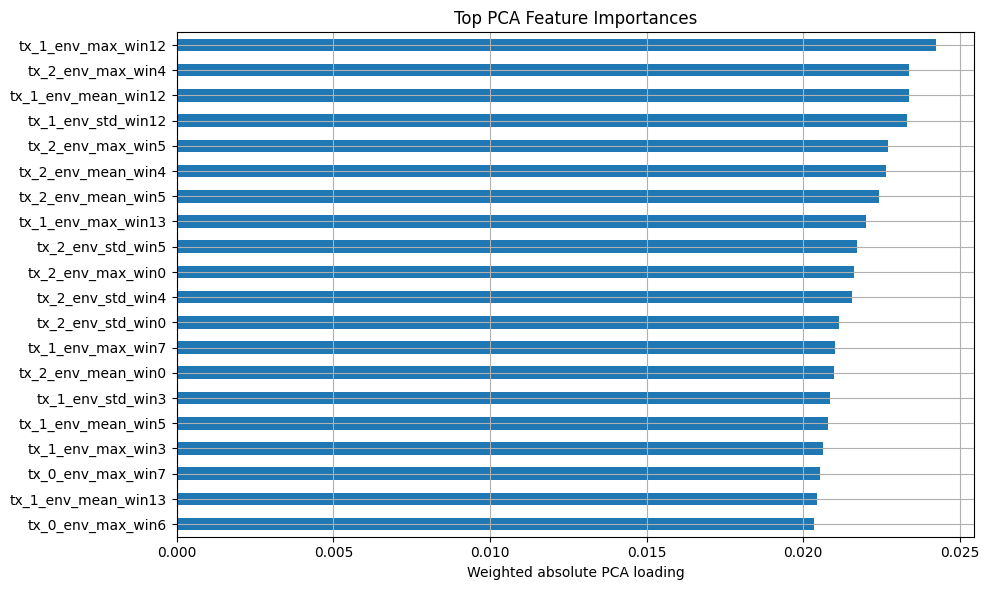

In [59]:
# Feature importance / loadings for each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=pca_feature_columns
)

# Absolute contribution to PC1/PC2
loadings_abs = loadings.abs()

print("\nTop features contributing to PC1:")
print(loadings_abs["PC1"].sort_values(ascending=False).head(15))

print("\nTop features contributing to PC2:")
print(loadings_abs["PC2"].sort_values(ascending=False).head(15))

# Combined importance across PC1 and PC2, weighted by explained variance
feature_importance = (
    loadings_abs["PC1"] * pca.explained_variance_ratio_[0]
    + loadings_abs["PC2"] * pca.explained_variance_ratio_[1]
)

feature_importance = feature_importance.sort_values(ascending=False)

print("\nOverall PCA feature importance:")
print(feature_importance.head(20))

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values().plot(kind="barh")
plt.xlabel("Weighted absolute PCA loading")
plt.title("Top PCA Feature Importances")
plt.grid(True)
plt.tight_layout()
plt.show()